# PyTorch Tutorial

Welcome to your first hands-on session! During 1 hour, we will learn the basics features of PyTorch.


# Outline
- [ 1 - Packages ](#1)
- [ 2 - Initialization](#2)
- [ 3 - Indexing](#3)
- [ 4 - Arithmetic operations](#4)
- [ 5 - Backpropagation](#5)
- [ 6 - GPU computation](#6)

<a name="1"></a>
## 1 - Packages

Let's first import the [numpy](https://numpy.org/) and [pytorch](https://pytorch.org/) packages.

In [ ]:
# Importing the packages might take some minutes
import numpy as np
import torch

# Even though PyTorch supports parallelism, we will be using only one CPU for this task
torch.set_num_threads(1)

<a name="2"></a>
## 2 - Initialization

PyTorch tensors are similar to Numpy arrays. 
In fact, many methods from Numpy exist for PyTorch tensors as well (e.g., `numpy.zeros` ≡ `torch.zeros`, `numpy.shape` ≡ `torch.shape`).
The main difference is that PyTorch tensors support GPU acceleration.

Tensors can be initialized in different ways:
- `torch.Tensor` to create a tensor without assignement:
```python
t = torch.Tensor(3, 4)
```
- `torch.zeros`, `torch.ones`, `torch.rand`, `torch.randn`, `torch.arange` to create a tensor with assignement:
```python
t = torch.ones(3, 4)
```
- `torch.from_numpy` to convert a Numpy array to a tensor:
```python
a = np.ones((3, 4))
t = torch.from_numpy(a)
```

<a name="3"></a>
### 3 Indexing
Indexing is handled as in Numpy. Values can be accessed by using sets of indices or using slices:

In [ ]:
t = torch.rand(3, 4)
print("\nTensor:\n", t)
print("\nElement 2nd row, 3rd column:", t[1,2])
print("\n2nd column:", t[:,1])

<a name="4"></a>
### 4 Arithmetic operations
PyTorch supports basic arithmetic operations (e.g., addition) as well as more complex operations (e.g., matrix multiplication).

In [ ]:
t1 = torch.arange(6).reshape(2,3)
t2 = t1.clone()
print("Tensor 1/2:\n", t1)
print("\nAddition:\n", t1 + t2)
print("\nElement-wise product:\n", t1 * t2)
print("\nMatrix multiplication:\n", torch.matmul(t1, t2.T))

Can you create the following matrix using the tensor t1 and two operations?

$$\begin{bmatrix} 1 & 4 \\ 2 & 5 \\ 3 & 6 \end{bmatrix}$$

What is the sum of all the elements of this matrix?

<a name="5"></a>
### 5 Backpropagation

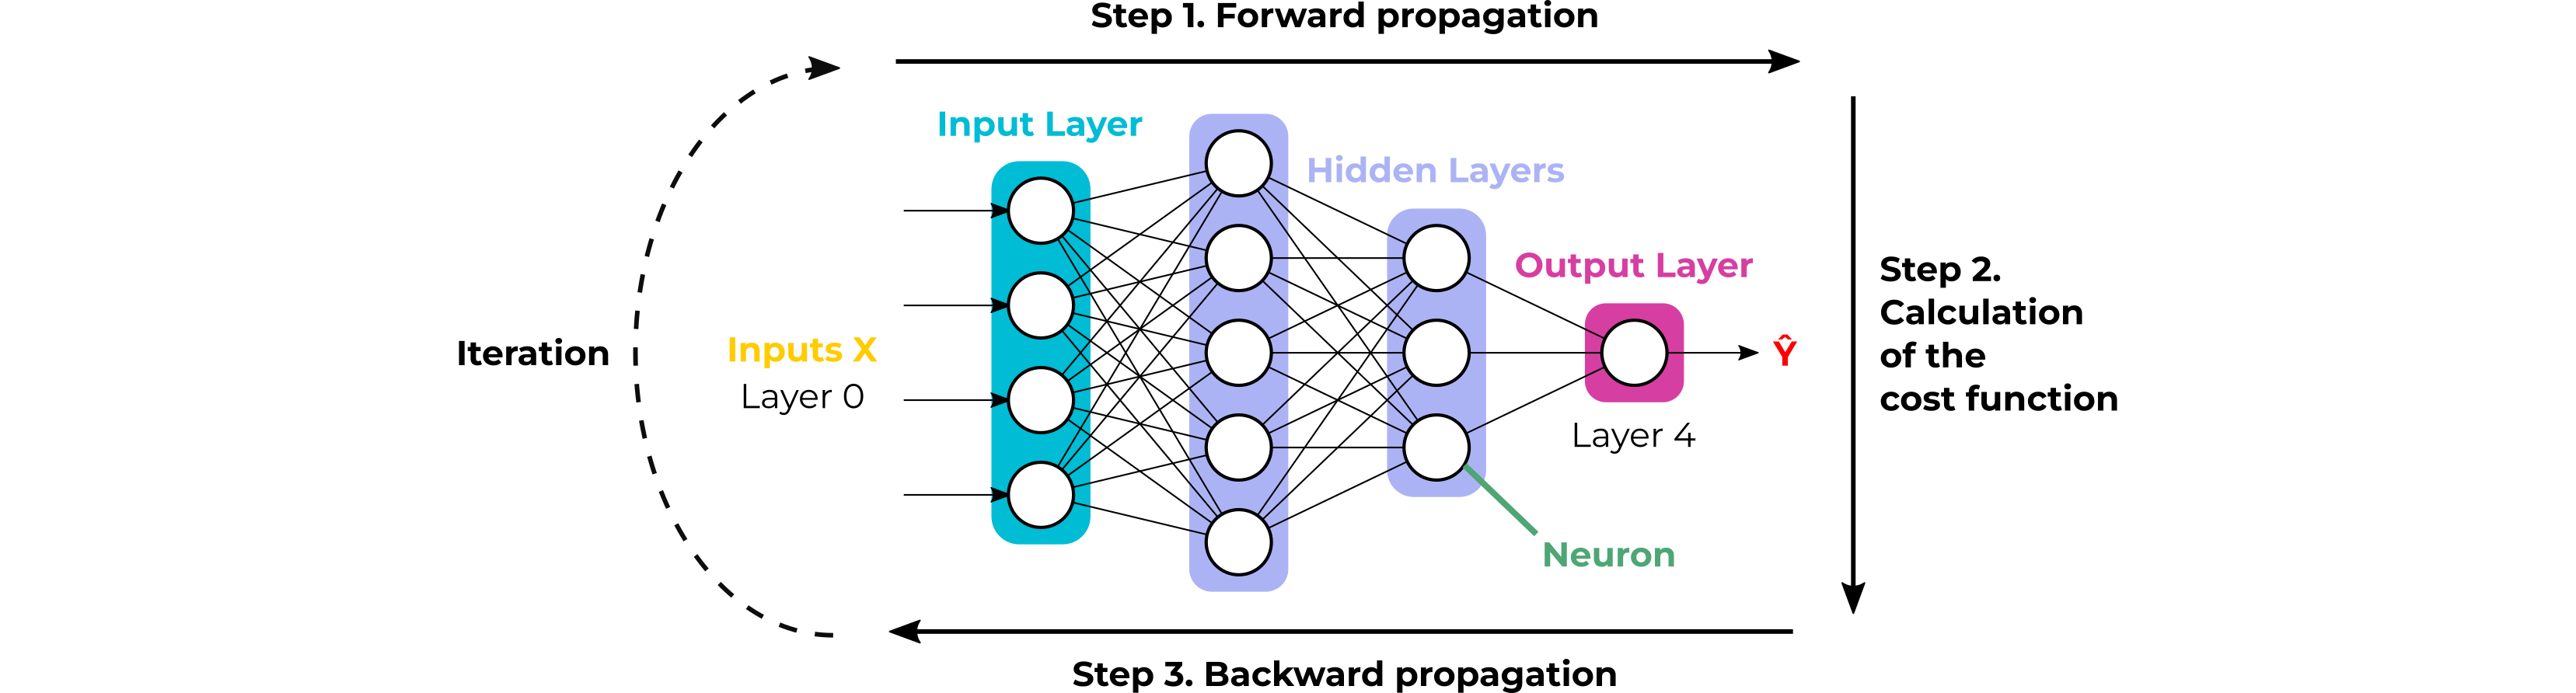

An optimization algorithm such as **gradient descent** requires the gradient of the loss function. Gradients can be efficiently computed by **backpropagating**, i.e., proceeding backwards through the feedforward network from the last layer through to the first.

PyTorch can keep tracks of the operations done on tensors and automatically get the gradients needed for the backpropagation.

This capability is disable by default. It can be enabled by using the `requires_grad_`method.

In [ ]:
t1 = torch.ones(1,3)
print("Does my tensor require gradients?", t1.requires_grad)

t1.requires_grad_(True)
print("Does my tensor require gradients?", t1.requires_grad)

We can build a *computation graph* by performing arithmetic operations and then calculate the gradients with `backward`:

In [ ]:
# t4 = 2 * (t1 + 2)^2
t1 = torch.ones(1, requires_grad=True)
t2 = t1 + 2
t3 = t2 ** 2
t4 = 2 * t3

print("Gradients before back propagation:", t1.grad)
t4.backward()
print("Gradients after back propagation:", t1.grad)

`backward` perfoms a backpropagation on the *computation graph* built up dynamically from the three arithmetic operations:

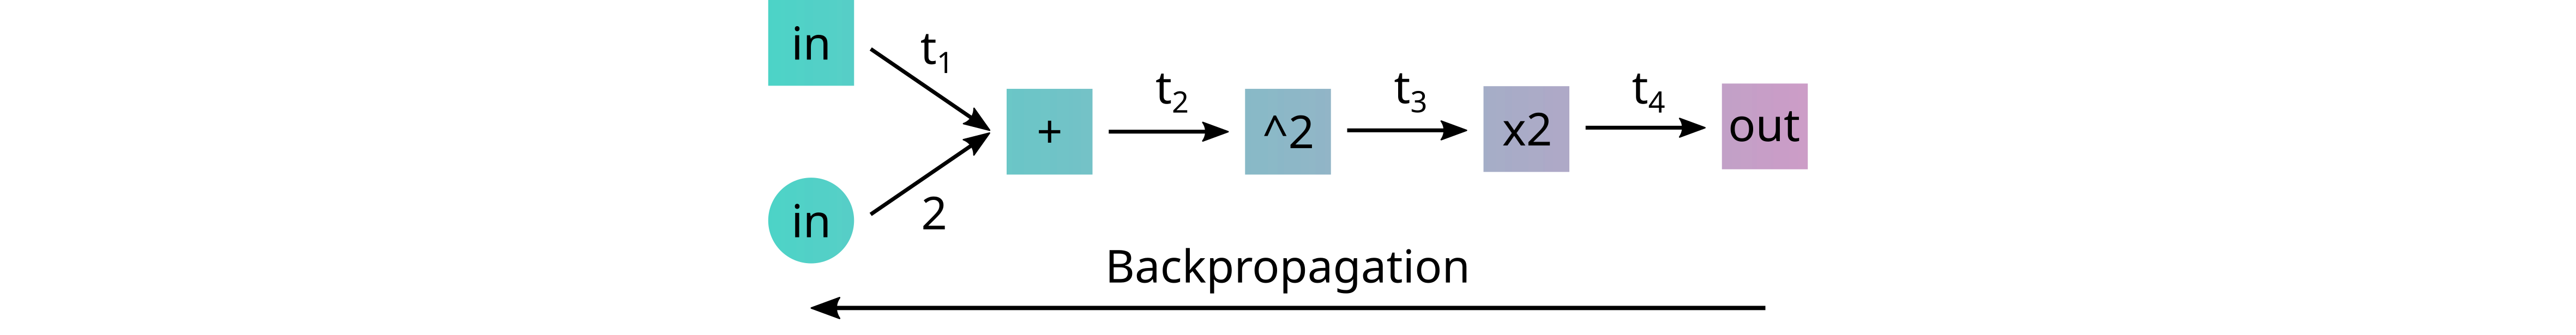

We can check the values of the computed gradients by using the chain rule:
$$
\frac{\partial t_4}{\partial t_1} = \frac{\partial t_4}{\partial t_3}\frac{\partial t_3}{\partial t_2}\frac{\partial t_2}{\partial t_1} = 12
$$

Where:
$$
\frac{\partial t_2}{\partial t_1} = 1
$$
$$
\frac{\partial t_3}{\partial t_2} = 2 * t_2 = 2 * (1 + 2) = 6
$$
$$
\frac{\partial t_4}{\partial t_3} = 2
$$

<a name="6"></a>
### 6 GPU computation

By default, all the created tensors are stored on CPUs. However, GPUs are generally more suitable for neural networks as they can perform many thousands of small operations in parallel.

To do so, models and tensors needed for the training have to be pushed to the GPU by using `.to(device)` or `.cuda()`.

In [ ]:
# We first check that the required NVIDIA drivers and CUDA libraries are installed
print("Can I use CUDA?", torch.cuda.is_available())

# If so, we can create an object "device" pointing to the GPU (assuming there is a GPU and CUDA/cuDNN libraries installed):
device = torch.device("cuda")

# It is common to setup the device automatically:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We can then push a tensor to the GPU:
t1 = torch.ones(10000, 10000)
print("Is my tensor on the GPU?", t1.is_cuda)
t2 = t1.to(device)
print("Is my tensor on the GPU?", t2.is_cuda)

Using t1 and t2, write a code (max. 10 lines in total) to show the computing speed difference between CPU and GPU.